In [ ]:
import pandas as pd

In [ ]:
import os

In [ ]:
data = {      "Student": ["A", "B", "C", "D", "E"],      "Math": [78, 90, 67, 95, 88],      "Science": [85, 88, 76, 92, 79],      "English": [82, 85, 80, 90, 84]  }

In [ ]:
df = pd.DataFrame(data)

In [ ]:
print(df)

  Student  Math  Science  English
0       A    78       85       82
1       B    90       88       85
2       C    67       76       80
3       D    95       92       90
4       E    88       79       84


In [ ]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Student', 'Math', 'Science', 'English'], dtype='object')


In [ ]:
print("\nIndex:")
print(df.index)


Index:
RangeIndex(start=0, stop=5, step=1)


In [ ]:
print("\nShape:")
print(df.shape)


Shape:
(5, 4)


In [ ]:
print("\nFirst 3 Rows:")
print(df.head(3))


First 3 Rows:
  Student  Math  Science  English
0       A    78       85       82
1       B    90       88       85
2       C    67       76       80


In [ ]:
df.to_csv("students.csv", index=False)


In [ ]:

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
/content


In [ ]:
df_csv = pd.read_csv("students.csv")

In [ ]:
print("\nCSV Data:")
print(df_csv)


CSV Data:
  Student  Math  Science  English
0       A    78       85       82
1       B    90       88       85
2       C    67       76       80
3       D    95       92       90
4       E    88       79       84


In [ ]:
print("\nData Types:")
print(df_csv.dtypes)


Data Types:
Student    object
Math        int64
Science     int64
English     int64
dtype: object


In [ ]:
print("\nMissing Values:")
print(df_csv.isnull().sum())


Missing Values:
Student    0
Math       0
Science    0
English    0
dtype: int64


In [ ]:
print("\nTotal Students:")
print(len(df_csv))


Total Students:
5


In [ ]:
df.to_json("students.json", orient="records", indent=4)

In [ ]:
df_json = pd.read_json("students.json")

In [ ]:
print("JSON Data")
print(df_json)

JSON Data
  Student  Math  Science  English
0       A    78       85       82
1       B    90       88       85
2       C    67       76       80
3       D    95       92       90
4       E    88       79       84


In [ ]:
print("\nComparison Between CSV and JSON")

print("""
CSV
----
• Table format
• Easy for Excel
• Less readable for nested data

JSON
-----
• Key-value format
• Human readable
• Best for APIs and web applications
""")


Comparison Between CSV and JSON

CSV
----
• Table format
• Easy for Excel
• Less readable for nested data

JSON
-----
• Key-value format
• Human readable
• Best for APIs and web applications



In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect("school.db")

In [ ]:
df.to_sql("students", conn, if_exists="replace", index=False)

5

In [ ]:
sql_df = pd.read_sql("SELECT * FROM students", conn)

In [ ]:
print(sql_df)

  Student  Math  Science  English
0       A    78       85       82
1       B    90       88       85
2       C    67       76       80
3       D    95       92       90
4       E    88       79       84


In [ ]:
print("\nStudents with Math > 80")

math_students = pd.read_sql(
    "SELECT * FROM students WHERE Math > 80",
    conn
)

print(math_students)


Students with Math > 80
  Student  Math  Science  English
0       B    90       88       85
1       D    95       92       90
2       E    88       79       84


In [ ]:
count = pd.read_sql(
    "SELECT COUNT(*) AS Total_Students FROM students",
    conn
)

print("\nTotal Records")
print(count)

conn.close()


Total Records
   Total_Students
0               5


In [ ]:
url = "https://www.w3schools.com/html/html_tables.asp"

tables = pd.read_html(url)

print("Total Tables Found:", len(tables))

df_web = tables[0]

print(df_web.head())

Total Tables Found: 2
                        Company          Contact  Country
0           Alfreds Futterkiste     Maria Anders  Germany
1    Centro comercial Moctezuma  Francisco Chang   Mexico
2                  Ernst Handel    Roland Mendel  Austria
3                Island Trading    Helen Bennett       UK
4  Laughing Bacchus Winecellars  Yoshi Tannamuri   Canada


In [ ]:
print("\nColumns")
print(df_web.columns)

print("\nNumber of Rows")
print(len(df_web))

print("\nGermany Companies")

germany = df_web[df_web["Country"] == "Germany"]

print(germany)


Columns
Index(['Company', 'Contact', 'Country'], dtype='object')

Number of Rows
6

Germany Companies
               Company       Contact  Country
0  Alfreds Futterkiste  Maria Anders  Germany


In [ ]:
df_web.to_csv("companies_web.csv", index=False)

print("\nCSV Saved Successfully")


CSV Saved Successfully


In [ ]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nMode")
print(df.mode(numeric_only=True))

print("\nVariance")
print(df.var(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
Math       83.6
Science    84.0
English    84.2
dtype: float64

Median
Math       88.0
Science    85.0
English    84.0
dtype: float64

Mode
   Math  Science  English
0    67       76       80
1    78       79       82
2    88       85       84
3    90       88       85
4    95       92       90

Variance
Math       124.3
Science     42.5
English     14.2
dtype: float64

Standard Deviation
Math       11.148991
Science     6.519202
English     3.768289
dtype: float64


In [ ]:
# Quartiles

Q1 = df.quantile(0.25, numeric_only=True)
Q2 = df.quantile(0.50, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)

IQR = Q3 - Q1

print("\nQ1")
print(Q1)

print("\nQ2")
print(Q2)

print("\nQ3")
print(Q3)

print("\nIQR")
print(IQR)


Q1
Math       78.0
Science    79.0
English    82.0
Name: 0.25, dtype: float64

Q2
Math       88.0
Science    85.0
English    84.0
Name: 0.5, dtype: float64

Q3
Math       90.0
Science    88.0
English    85.0
Name: 0.75, dtype: float64

IQR
Math       12.0
Science     9.0
English     3.0
dtype: float64


In [ ]:
# Range

range_values = df.max(numeric_only=True) - df.min(numeric_only=True)

print("\nRange")
print(range_values)

# Hardest Subject

means = df.mean(numeric_only=True)

hardest = means.idxmin()

print("\nHardest Subject")
print(hardest)

# Most Inconsistent Subject

variance = df.var(numeric_only=True)

inconsistent = variance.idxmax()

print("\nMost Inconsistent Subject")
print(inconsistent)


Range
Math       28
Science    16
English    10
dtype: int64

Hardest Subject
Math

Most Inconsistent Subject
Math


In [ ]:
mean_scores = df[["Math", "Science", "English"]].mean()

above_all = df[
    (df["Math"] > mean_scores["Math"]) &
    (df["Science"] > mean_scores["Science"]) &
    (df["English"] > mean_scores["English"])
]

print("Students Above Average in All Subjects")
print(above_all)

print("\nSorted by English Marks")

print(df.sort_values(by="English", ascending=False))



print("\nAbove Average in Math Only")

math_above = df[df["Math"] > mean_scores["Math"]]

print(math_above)

# Overall Total

df["Total"] = df[["Math", "Science", "English"]].sum(axis=1)

print("\nTop 2 Students")

print(df.sort_values(by="Total", ascending=False).head(2))

Students Above Average in All Subjects
  Student  Math  Science  English
1       B    90       88       85
3       D    95       92       90

Sorted by English Marks
  Student  Math  Science  English
3       D    95       92       90
1       B    90       88       85
4       E    88       79       84
0       A    78       85       82
2       C    67       76       80

Above Average in Math Only
  Student  Math  Science  English
1       B    90       88       85
3       D    95       92       90
4       E    88       79       84

Top 2 Students
  Student  Math  Science  English  Total
3       D    95       92       90    277
1       B    90       88       85    263


In [ ]:
import numpy as np

data = {
    "Student": ["A", "B", "C", "D", "E"],
    "Math": [78, None, 67, 95, 88],
    "Science": [85, 88, "absent", 92, 79],
    "English": [82, 85, 80, 90, None]
}

dirty_df = pd.DataFrame(data)

print("Dirty Data")

print(dirty_df)

# Task 1

print("\nMissing Values")

print(dirty_df.isnull().sum())

# Task 2

dirty_df["Science"] = dirty_df["Science"].replace("absent", np.nan)

dirty_df["Science"] = pd.to_numeric(dirty_df["Science"])

science_mean = dirty_df["Science"].mean()

dirty_df["Science"] = dirty_df["Science"].fillna(science_mean)

# Task 3

dirty_df["Math"] = dirty_df["Math"].fillna(dirty_df["Math"].mean())

dirty_df["English"] = dirty_df["English"].fillna(dirty_df["English"].mean())

# Task 4

dirty_df["Math"] = pd.to_numeric(dirty_df["Math"])

dirty_df["Science"] = pd.to_numeric(dirty_df["Science"])

dirty_df["English"] = pd.to_numeric(dirty_df["English"])

print("\nCleaned Data")

print(dirty_df)

print("\nData Types")

print(dirty_df.dtypes)

Dirty Data
  Student  Math Science  English
0       A  78.0      85     82.0
1       B   NaN      88     85.0
2       C  67.0  absent     80.0
3       D  95.0      92     90.0
4       E  88.0      79      NaN

Missing Values
Student    0
Math       1
Science    0
English    1
dtype: int64

Cleaned Data
  Student  Math  Science  English
0       A  78.0     85.0    82.00
1       B  82.0     88.0    85.00
2       C  67.0     86.0    80.00
3       D  95.0     92.0    90.00
4       E  88.0     79.0    84.25

Data Types
Student     object
Math       float64
Science    float64
English    float64
dtype: object


/tmp/ipykernel_851/4291609467.py:24: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dirty_df["Science"] = dirty_df["Science"].replace("absent", np.nan)


In [ ]:
df["Total"] = df[["Math", "Science", "English"]].sum(axis=1)

df.to_csv("processed_students.csv", index=False)

print("Processed CSV Saved Successfully")

print(df)

Processed CSV Saved Successfully
  Student  Math  Science  English  Total
0       A    78       85       82    245
1       B    90       88       85    263
2       C    67       76       80    223
3       D    95       92       90    277
4       E    88       79       84    251


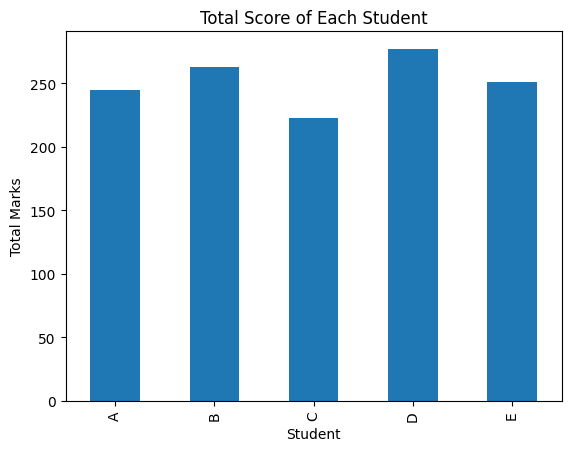

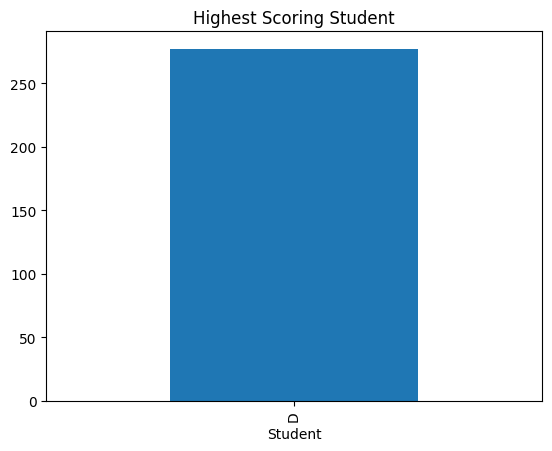

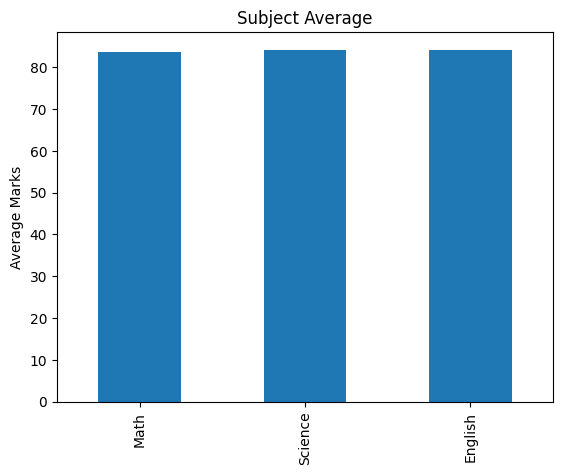

In [ ]:
import matplotlib.pyplot as plt

# Total Score Bar Chart

df.plot(
    x="Student",
    y="Total",
    kind="bar",
    legend=False
)

plt.title("Total Score of Each Student")
plt.xlabel("Student")
plt.ylabel("Total Marks")

plt.show()

# -------------------------
# Highest Scoring Student
# -------------------------

highest = df.sort_values(by="Total", ascending=False).head(1)

highest.plot(
    x="Student",
    y="Total",
    kind="bar",
    legend=False
)

plt.title("Highest Scoring Student")

plt.show()

# -------------------------
# Subject Average
# -------------------------

subject_average = df[
    ["Math", "Science", "English"]
].mean()

subject_average.plot(kind="bar")

plt.title("Subject Average")

plt.ylabel("Average Marks")

plt.show()

  Student  Math  Science  English  Computer
0       A    72       81       77        90
1       B    88       79       92        85
2       C    65       72       70        60
3       D    95       90       85        93
4       E    80       85       79        88
5       F    90       93       95        97
6       G    55       60       58        65
7       H    84       78       83        80

CSV Saved
JSON Saved
Database Saved

Mean
Math        78.625
Science     79.750
English     79.875
Computer    82.250
dtype: float64

Median
Math        82.0
Science     80.0
English     81.0
Computer    86.5
dtype: float64

Variance
Math        186.267857
Science     109.071429
English     142.410714
Computer    175.928571
dtype: float64

Standard Deviation
Math        13.647998
Science     10.443727
English     11.933596
Computer    13.263807
dtype: float64

Student Totals
  Student  Total
0       A    320
1       B    344
2       C    267
3       D    363
4       E    332
5       F    375
6   

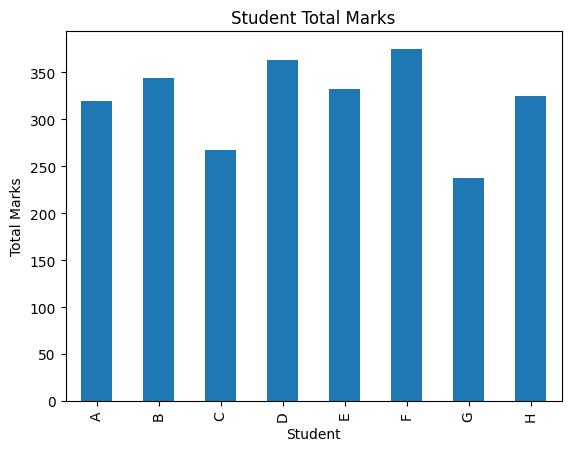

In [ ]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


# Create Dataset


data = {
    "Student": ["A","B","C","D","E","F","G","H"],
    "Math": [72,88,65,95,80,90,55,84],
    "Science": [81,79,72,90,85,93,60,78],
    "English": [77,92,70,85,79,95,58,83],
    "Computer": [90,85,60,93,88,97,65,80]
}

df = pd.DataFrame(data)

print(df)


# Save CSV


df.to_csv("final_students.csv", index=False)

print("\nCSV Saved")


# Convert JSON


df.to_json("final_students.json", orient="records", indent=4)

print("JSON Saved")

# Store SQL

conn = sqlite3.connect("final_school.db")

df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Database Saved")


# Statistics


print("\nMean")

print(df.mean(numeric_only=True))

print("\nMedian")

print(df.median(numeric_only=True))

print("\nVariance")

print(df.var(numeric_only=True))

print("\nStandard Deviation")

print(df.std(numeric_only=True))


# Total Marks


df["Total"] = df[
    ["Math","Science","English","Computer"]
].sum(axis=1)

print("\nStudent Totals")

print(df[["Student","Total"]])

# Topper


topper = df.sort_values(
    by="Total",
    ascending=False
)

print("\nTopper")

print(topper.head(1))

print("\nTop 3 Students")

print(topper.head(3))

# Plot Total Marks

df.plot(
    x="Student",
    y="Total",
    kind="bar",
    legend=False
)

plt.title("Student Total Marks")

plt.xlabel("Student")

plt.ylabel("Total Marks")

plt.show()

conn.close()